In [158]:
import sys
print(sys.executable)

/Users/nicole/data-training/.venv/bin/python


In [336]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 
import numpy as np
import json

from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score,average_precision_score

In [209]:
# read bigquery data into pandas dataframe
import pandas as pd

df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.cafe.cafe-sales`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
    location="australia-southeast1",
)

/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_94992/1097260367.py:4: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(


In [210]:
# Drop the unnecessary columns
df.drop(columns=['ip_addr', 'date_paid', 'status', 'items'], inplace=True)

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37372 entries, 0 to 37371
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      37372 non-null  Int64         
 1   customer_id   37372 non-null  Int64         
 2   date_created  37372 non-null  datetime64[us]
 3   total         37372 non-null  Int64         
dtypes: Int64(3), datetime64[us](1)
memory usage: 1.2 MB


### Create customer infomation table

- period: 2019-2020.12.31, 2021-2021.12.31, 2022-2024

In [212]:
def create_rfm_table(df, date_start, date_end, period=60):
    """
    Create the rfm table based of the given period of time.
    Churn: 1 for no transaction made in the observation period, vice versa

    :param date_start: The starting date of the dataset
    :param date_end: The ending date of the dataset
    :param period: Observation period, default 60 days
    :return: Return the rfm table created based on the period dataset
    """ 
    
    period_start = date_end - pd.DateOffset(days=period)

    table = df.copy()
    table.set_index('date_created', inplace=True) # setting Date as index
    table.sort_index(inplace=True)

    df_part1 = table.loc[date_start:period_start] # part of data that doesn't have last 60 days of transaction
    df_part1_obs = table.loc[period_start:date_end] # part of data that have only last 60 days of transaction

    # reseting the index
    df_part1.reset_index(inplace=True)
    df_part1_obs.reset_index(inplace=True)

    ## calculate the rfm
    rfm_df = df_part1.groupby('customer_id').agg(
        recency=('date_created', lambda x: (df_part1['date_created'].max() - x.max()).days),
        frequency=('date_created', 'count'),
        monetary=('total', 'sum')
    ).reset_index()

    # getting the number of customers in part1 and part2
    part1_customer = df_part1['customer_id'].sort_values().unique()
    part1_obs_customer = df_part1_obs['customer_id'].sort_values().unique()

    # finding whether the customer is churned or not
    rfm_df['churn'] = [0 if customer in part1_obs_customer else 1 for customer in part1_customer]

    # drop the customer_id as unnecessary
    rfm_df.drop(['customer_id'], axis= 1, inplace= True)

    return rfm_df

In [213]:
first_order_dates = df['date_created'].min()
period_1 = pd.Timestamp('2020-12-31')
period_2 = pd.Timestamp('2021-12-31')
last_order_dates = df['date_created'].max()

rfm_part1 = create_rfm_table(df, first_order_dates, period_1)
rfm_part2 = create_rfm_table(df, period_1, period_2)
rfm_part3 = create_rfm_table(df, period_2, last_order_dates)

rfm_table = pd.concat([rfm_part1, rfm_part2,rfm_part3], axis=0)

In [220]:
rfm_table.churn.value_counts()

churn
1    1663
0     575
Name: count, dtype: int64

### Model

#### Data standardization & Data splitting

In [236]:
X = rfm_table.drop(['churn'], axis= 1)
y = rfm_table[['churn']].values.reshape(-1)

In [237]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and Transform The Data
X = scaler.fit_transform(X)

In [238]:
from sklearn.model_selection import train_test_split

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, shuffle=True)

#### Model prediction

In [239]:
from imblearn.over_sampling import SMOTE

oversample = SMOTE()

X_train_over, y_train_over = oversample.fit_resample(X_train, y_train)


#### LGB

In [232]:
import lightgbm as lgb

In [338]:
params = {
'objective': 'binary',
'boosting_type': 'gbdt',
'metric':'auc',
'is_unbalance': 'true',
'num_leaves': 31,
'learning_rate': 0.05,
"verbose": 0,
}

lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

clf = lgb.train(params,
                lgb_train, 
                valid_sets=lgb_eval,
                valid_names=['train','test'],
                num_boost_round=20,
                callbacks=[lgb.early_stopping(stopping_rounds=10),])

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	train's auc: 0.863664


In [339]:
y_pred_proba = clf.predict(X_test, num_iteration=clf.best_iteration)
y_pred = (y_pred_proba >= 0.5).astype("int")
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
    
print('The accuracy of prediction is:', accuracy)
print('The ROC AUC of prediction is:', roc_auc)
print('The F1 Score of prediction is:', f1)
print('The Precision of prediction is:', prec)
print('The Recall of prediction is:', rec)

The accuracy of prediction is: 0.7433035714285714
The ROC AUC of prediction is: 0.8635853244548897
The F1 Score of prediction is: 0.852752880921895
The Precision of prediction is: 0.7433035714285714
The Recall of prediction is: 1.0


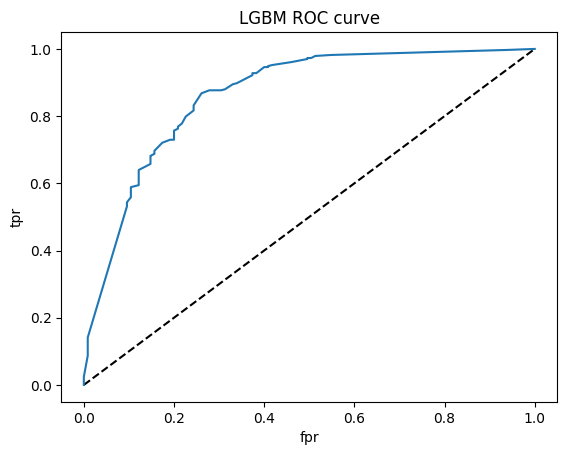

In [340]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='LGBM')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title(f'LGBM ROC curve')
plt.show()

#### LGBMClassifier 测试

In [343]:
clf_binary = lgb.LGBMClassifier(**params).fit(X_train, y_train)

predictions = clf_binary.predict_proba(X_test)

acc_bin  = accuracy_score(y_test, predictions[:,1] >= 0.5)
roc_auc   = roc_auc_score(y_test, predictions[:,1])
prec = precision_score(y_test, predictions[:,1] >= 0.5)
rec    = recall_score(y_test, predictions[:,1] >= 0.5)
pr_auc    = average_precision_score(y_test, predictions[:,1])

print('The accuracy of prediction is:', acc_bin)
print('The ROC AUC of prediction is:', roc_auc)
print('The Precision of prediction is:', prec)
print('The Recall of prediction is:', rec)

The accuracy of prediction is: 0.7433035714285714
The ROC AUC of prediction is: 0.8680506593550071
The Precision of prediction is: 0.9104938271604939
The Recall of prediction is: 0.8858858858858859


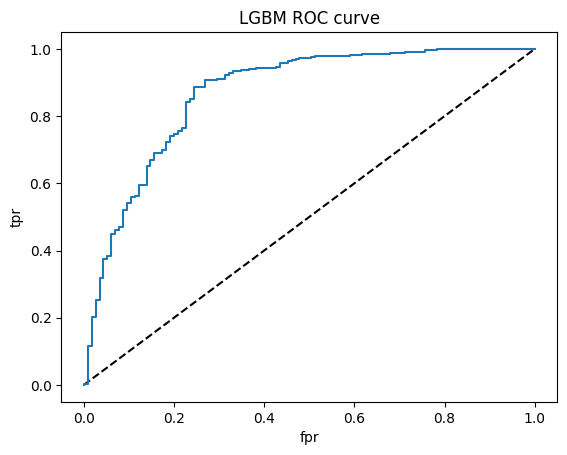

In [344]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, predictions[:,1])

plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='LGBM')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title(f'LGBM ROC curve')
plt.show()

In [345]:
print(classification_report(y_test, predictions[:,1] >= 0.5))

              precision    recall  f1-score   support

           0       0.69      0.75      0.72       115
           1       0.91      0.89      0.90       333

    accuracy                           0.85       448
   macro avg       0.80      0.82      0.81       448
weighted avg       0.85      0.85      0.85       448



#### RANDOM FOREST

In [346]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=20,class_weight='balanced').fit(X_train, y_train)
#rf_over = RandomForestClassifier(n_estimators=20).fit(X_train_over, y_train_over)

In [347]:
predictions = pd.DataFrame()
predictions['true'] = y_train
predictions['preds'] = rf.predict(X_train)

In [348]:
predictions_test = pd.DataFrame()
predictions_test['true'] = y_test
predictions_test['preds'] = rf.predict(X_test)
#predictions_test['preds_over'] = rf_over.predict(X_test)

In [349]:
from sklearn.metrics import classification_report, accuracy_score
train_acc = accuracy_score(predictions.true, predictions.preds)
test_acc = accuracy_score(predictions_test.true, predictions_test.preds)
#test_acc_over = accuracy_score(predictions_test.true, predictions_test.preds_over)


print(f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Train Acc: 0.9911, Test Acc: 0.8438


In [351]:
print(classification_report(predictions_test.true, predictions_test.preds))

              precision    recall  f1-score   support

           0       0.72      0.63      0.68       115
           1       0.88      0.92      0.90       333

    accuracy                           0.84       448
   macro avg       0.80      0.78      0.79       448
weighted avg       0.84      0.84      0.84       448



/Users/nicole/data-training/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


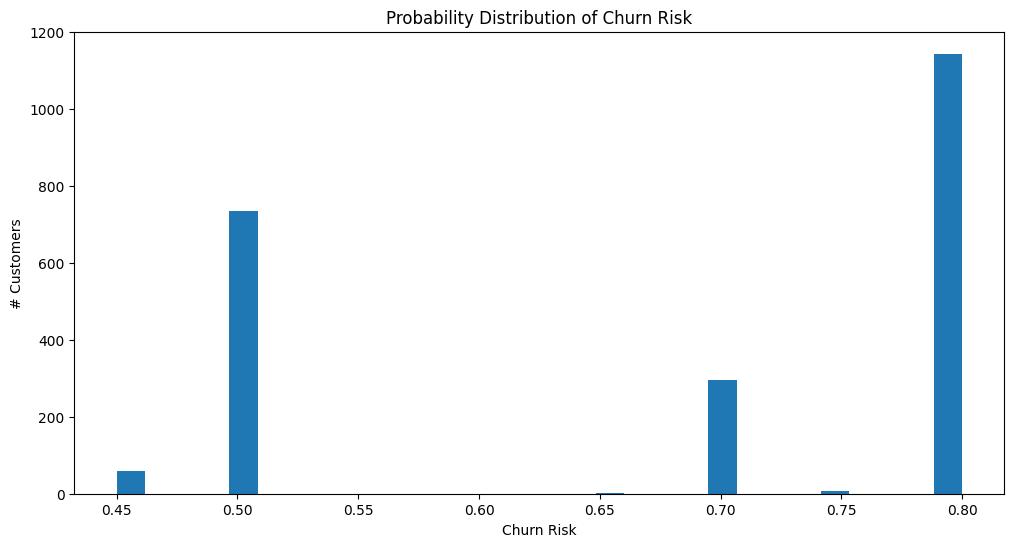

In [352]:
current_rfm = rfm_table.copy()
current_rfm.drop(columns=['churn'], inplace=True)
probs = rf.predict_proba(current_rfm)[:, 1]

plt.figure(figsize=(12, 6))
# matplotlib histogram
plt.hist(probs, bins = int(180/6))

plt.title('Probability Distribution of Churn Risk')
plt.xlabel('Churn Risk')
plt.ylabel('# Customers')
plt.show()